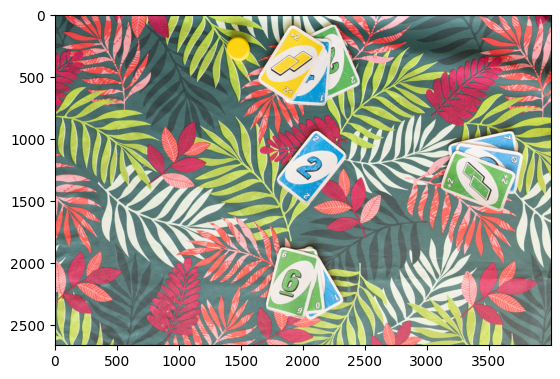

In [1]:
from importlib import reload
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from PIL import Image

import card_detection_helpers as helpers
reload(helpers)
from card_detection_helpers import *
BASE_DIR = Path.cwd().parent
TRAIN_DIR = BASE_DIR / "iapr-26-uno-vision-challenge" / "train_images"

image_paths = sorted(TRAIN_DIR.glob("*.jpg"))

'''for i in range(30):
    img_color = Image.open(image_paths[i]).convert("RGB")
    print(i)
    masks, edges = white_frames_segmentation_pipeline(img_color)
    show_cards_on_frame(img_color, edges)
    plt.show()'''

img_color = Image.open(TRAIN_DIR / "L1000973.jpg").convert("RGB")
#img_color = Image.open(BASE_DIR / "iapr-26-uno-vision-challenge" / "reference_images" / "L1000766.jpg").convert("RGB")
plt.imshow(img_color)

## Find image type

In [2]:
grey_mean = float(np.array(img_color, dtype=np.float32).mean())
print(f"Grayscale mean: {grey_mean:.2f}")

if grey_mean < 185:
    print("Dark background: yellow token")
    token = "yellow"
else:
    print("Light background: grey token")
    token = "grey"

Grayscale mean: 141.23
Dark background: yellow token


## Get color masks

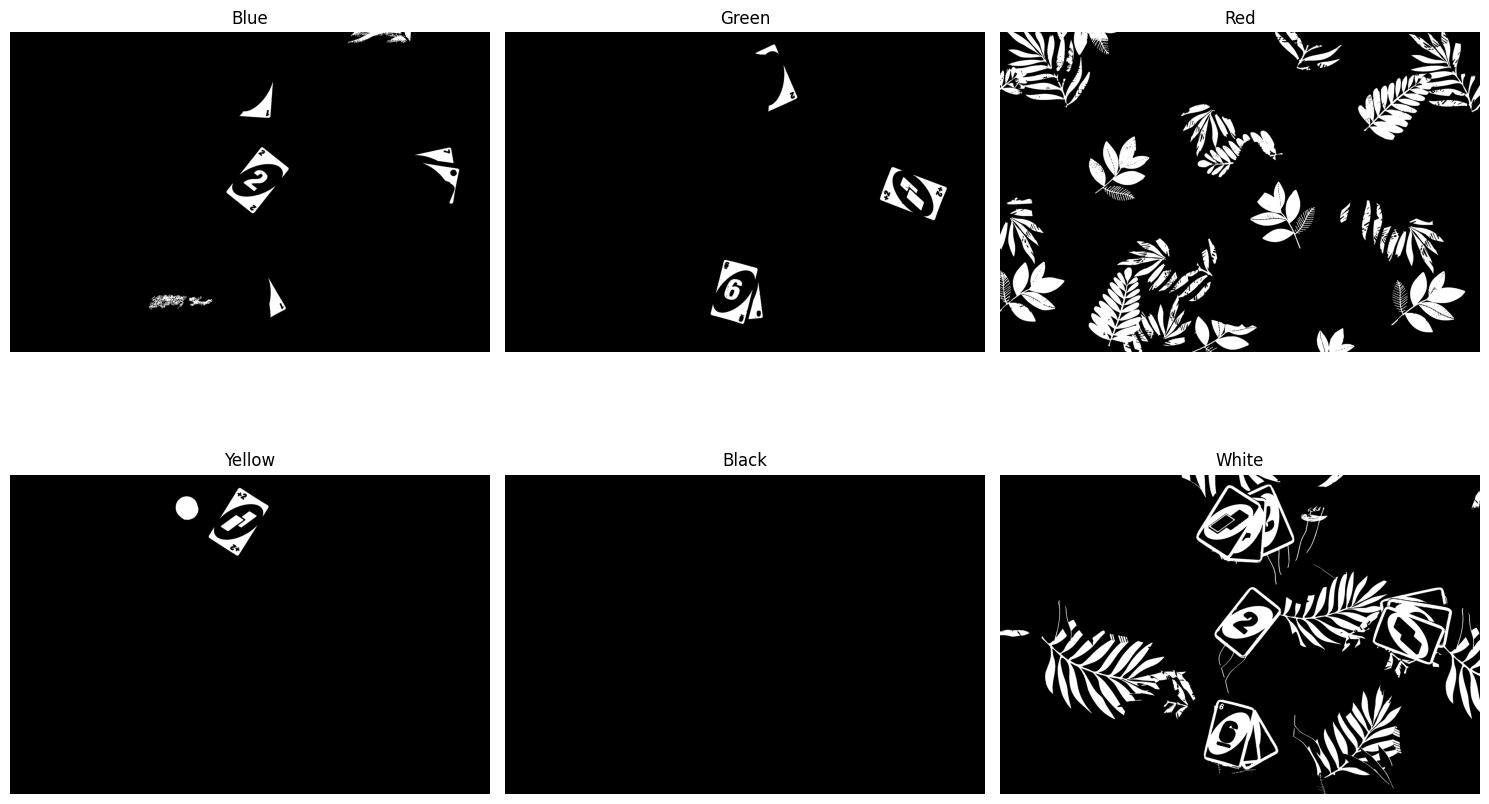

In [3]:
import re

HSV_DIR = BASE_DIR / "hsv_thresholds"
COLORS = ["blue", "green", "red", "yellow", "black", "white"]
MIN_OBJECT_AREA = 5000


def load_hsv_ranges(color):
    threshold_path = HSV_DIR / f"{color}_hsv.txt"
    text = threshold_path.read_text()
    ranges = []
    idx = 1

    while True:
        lower_match = re.search(rf"lower_hsv_{idx}\s*=\s*np\.array\(\[([^\]]+)\]\)", text)
        upper_match = re.search(rf"upper_hsv_{idx}\s*=\s*np\.array\(\[([^\]]+)\]\)", text)

        if lower_match is None or upper_match is None:
            break

        lower = np.array([int(value.strip()) for value in lower_match.group(1).split(",")], dtype=np.uint8)
        upper = np.array([int(value.strip()) for value in upper_match.group(1).split(",")], dtype=np.uint8)
        ranges.append((lower, upper))
        idx += 1

    if not ranges:
        raise ValueError(f"No HSV ranges found in {threshold_path}")

    return ranges



def color_mask_from_threshold_file(img_color, color):
    hsv = cv2.cvtColor(np.array(img_color), cv2.COLOR_RGB2HSV)
    combined_mask = np.zeros(hsv.shape[:2], dtype=np.uint8)

    for lower, upper in load_hsv_ranges(color):
        current_mask = cv2.inRange(hsv, lower, upper)
        combined_mask = cv2.bitwise_or(combined_mask, current_mask)

    return combined_mask



color_masks = {
    color: color_mask_from_threshold_file(img_color, color)
    for color in COLORS
}

for color, mask in color_masks.items():
    closed_mask = helpers.close(3, 1, mask)
    color_masks[color] = helpers.min_area_filter(closed_mask, MIN_OBJECT_AREA)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for ax, color in zip(axes, COLORS):
    ax.imshow(color_masks[color], cmap="gray")
    ax.set_title(color.capitalize())
    ax.axis("off")

plt.tight_layout()
plt.show()


## Find yellow token

{'center': (1474, 278), 'radius': 94, 'score': 0.9226896029427676, 'fill_score': 0.9826896029427675, 'radius_error': 0.06}


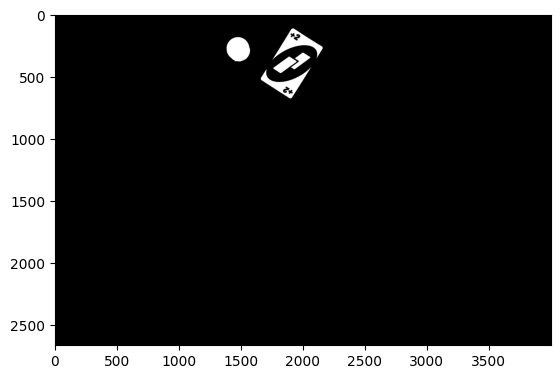

In [4]:
if token == "yellow":
    coords = helpers.find_circle_hough(mask = color_masks["yellow"], expected_radius=100, radius_tolerance=50)
    print(coords)
    plt.imshow(color_masks["yellow"], cmap="gray")
    

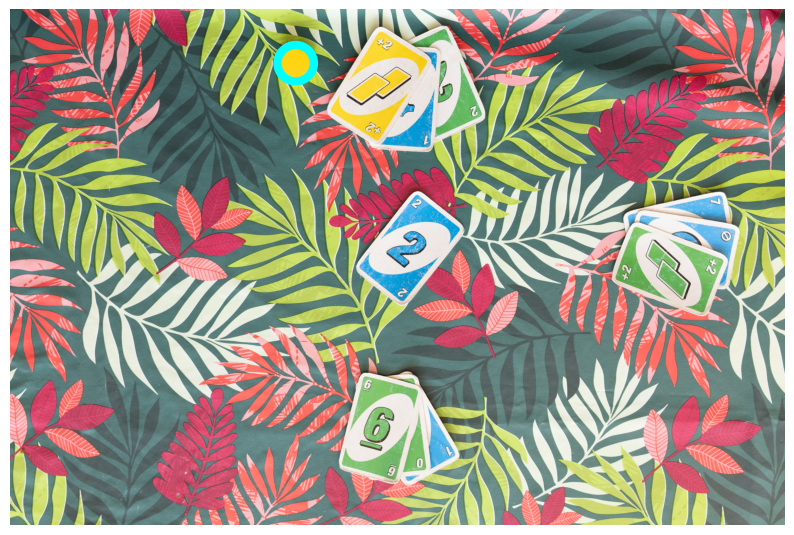

In [5]:
if token == "yellow":
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img_color)

    x, y = coords["center"]
    r = coords["radius"]

    circle_patch = Circle(
        (x, y),
        r,
        fill=False,
        edgecolor="cyan",
        linewidth=6,
    )

    ax.add_patch(circle_patch)
    ax.axis("off")
    plt.show()


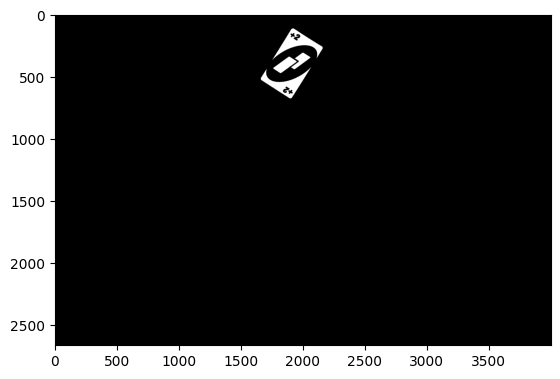

In [6]:
if token == "yellow":
    token_mask = np.ones_like(color_masks["yellow"], dtype=np.uint8)
    x, y = coords["center"]
    r = coords["radius"]*1.2
    cv2.circle(
        token_mask,
        (int(x), int(y)),
        int(r),
        0,   # mask value
        -1     # filled
    )

    color_masks["yellow"] = cv2.bitwise_and(color_masks["yellow"], color_masks["yellow"], mask=token_mask)
    plt.imshow(color_masks["yellow"], cmap="gray")

## Find grey token

In [7]:
if token == "grey":
    threshold_path = HSV_DIR / f"grey_hsv.txt"
    text = threshold_path.read_text()
    lower_match = re.search(rf"lower_hsv_{1}\s*=\s*np\.array\(\[([^\]]+)\]\)", text)
    upper_match = re.search(rf"upper_hsv_{1}\s*=\s*np\.array\(\[([^\]]+)\]\)", text)
    lower = np.array([int(value.strip()) for value in lower_match.group(1).split(",")], dtype=np.uint8)
    upper = np.array([int(value.strip()) for value in upper_match.group(1).split(",")], dtype=np.uint8)
    hsv = cv2.cvtColor(np.array(img_color), cv2.COLOR_RGB2HSV)
    grey_mask = cv2.inRange(hsv, lower, upper)
    token_mask = helpers.biggest_object(grey_mask)
    center = helpers.mask_center(token_mask)
    print("Grey mask center: ", center)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img_color)
    x, y = center
    circle_patch = Circle(
        (x, y),
        20,
        fill=True,
        edgecolor="cyan",
        linewidth=6,
    )
    ax.add_patch(circle_patch)
    ax.axis("off")
    plt.show()

In [8]:
if token == "grey":
    color_masks["black"] = color_masks["black"] &~token_mask
    color_masks["black"] = helpers.min_area_filter(color_masks["black"], MIN_OBJECT_AREA)
    plt.imshow(color_masks["black"], cmap="gray")

## Keeping only white connected objects

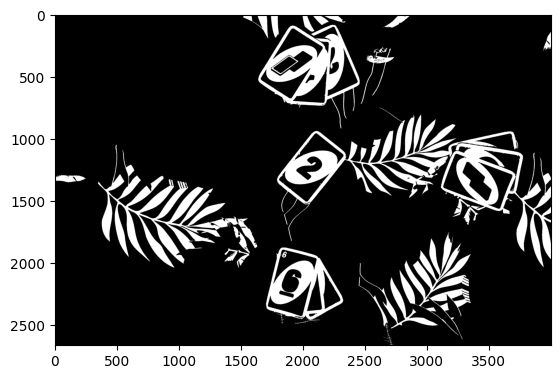

In [9]:
plt.imshow(color_masks["white"], cmap="gray")

blue: kept 7/10 objects
green: kept 8/10 objects
red: kept 0/55 objects
yellow: kept 3/4 objects
black: kept 0/0 objects


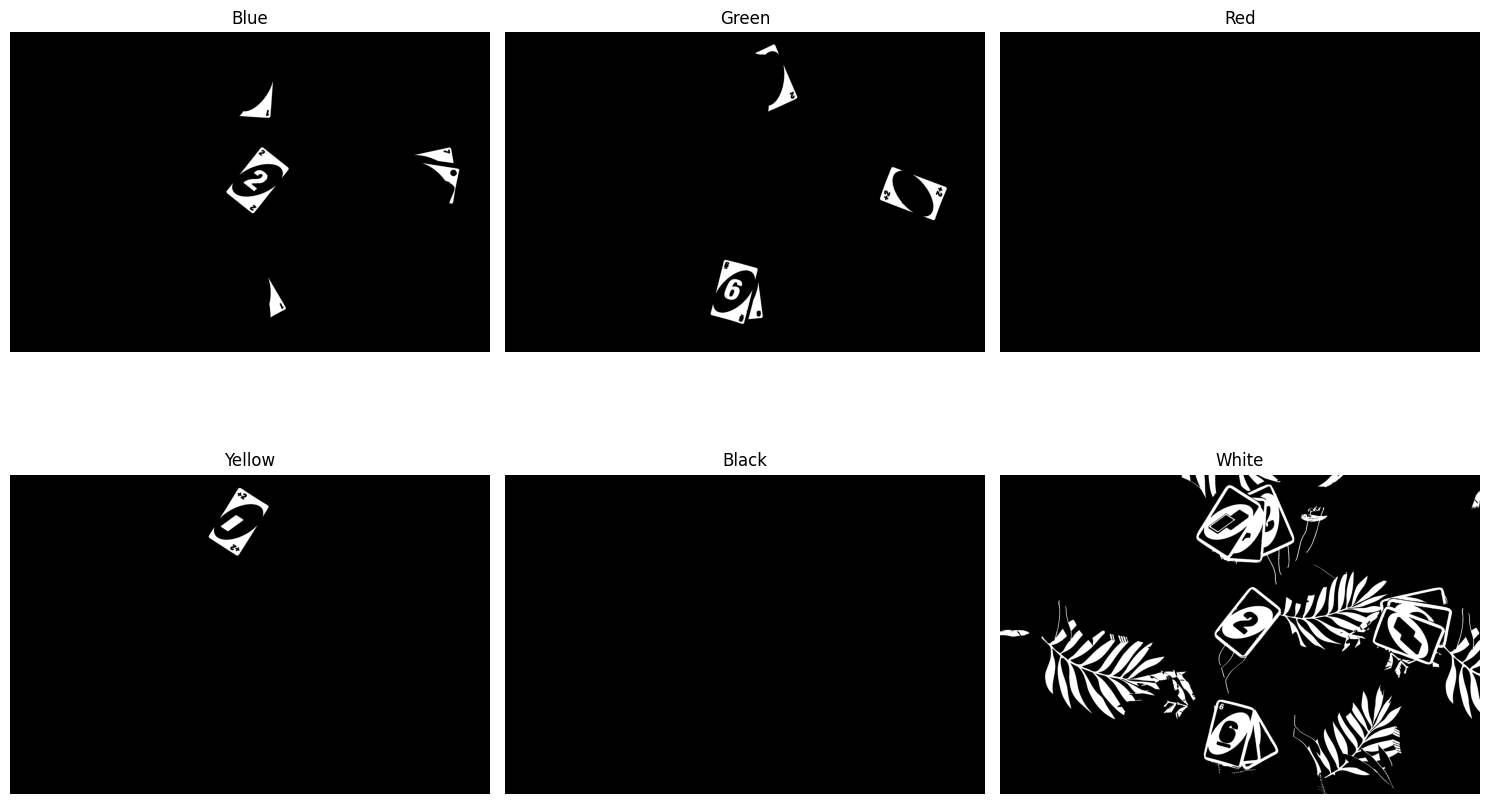

In [10]:
WHITE_SURROUND_THRESHOLD = 0.5
SURROUND_RING_RADIUS = 20
OBJECT_COLORS = [color for color in COLORS if color != "white"]


surrounded_scores = {}

for color in OBJECT_COLORS:
    filtered_mask, scores = helpers.keep_objects_surrounded_by_white(
        color_masks[color],
        color_masks["white"],
        WHITE_SURROUND_THRESHOLD,
        SURROUND_RING_RADIUS,
    )
    filtered_mask = helpers.close(5, 1, filtered_mask)
    color_masks[color] = filtered_mask
    surrounded_scores[color] = scores
    kept_count = sum(score["kept"] for score in scores)
    print(f"{color}: kept {kept_count}/{len(scores)} objects")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for ax, color in zip(axes, COLORS):
    ax.imshow(color_masks[color], cmap="gray")
    ax.set_title(color.capitalize())
    ax.axis("off")

plt.tight_layout()
plt.show()


## Extracting all holes

In [11]:
hole_mask = np.zeros_like(color_masks["white"], dtype=np.uint8)

for col, mask in color_masks.items():
    if col == "white":
        continue
    col_mask = helpers.get_holes(mask, min_hole_area=100)
    hole_mask = cv2.bitwise_or(hole_mask, col_mask)

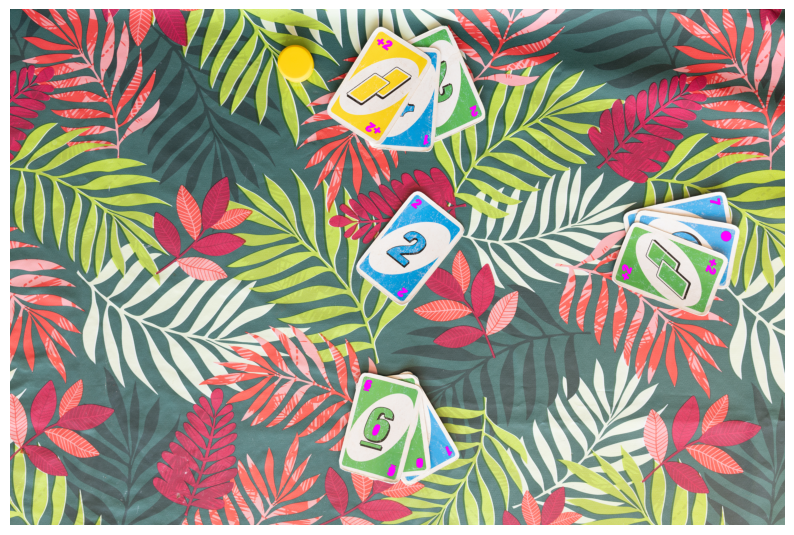

In [12]:
holes_in_color = np.array(img_color).copy()
holes_in_color[hole_mask > 0] = [255, 0, 255]  # magenta for holes

plt.figure(figsize=(10, 8))
plt.imshow(holes_in_color)
plt.axis("off")
plt.show()



## Filter out center holes

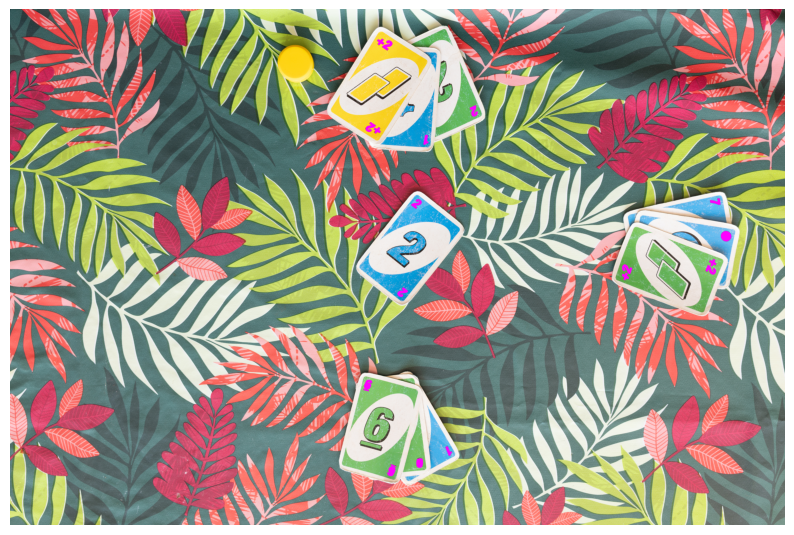

True

In [13]:
symbols_mask_per_color = {}

for col, mask in color_masks.items():
    if col == "white":
        continue

    hole_mask = helpers.get_holes(mask, min_hole_area=100)

    hole_mask_filtered = helpers.filter_shapes_by_dilated_ring_overlap_binary(
        hole_mask,
        color_masks["white"],
        dilation_radius=20,
        min_white_pixels=50
    )
    symbols_mask_per_color[col] = hole_mask_filtered

total_hole_mask = np.bitwise_or.reduce(list(symbols_mask_per_color.values()))
        
holes_in_color_filtered = np.array(img_color).copy()
holes_in_color_filtered[total_hole_mask > 0] = [255, 0, 255]  # magenta for holes

plt.figure(figsize=(10, 8))
plt.imshow(holes_in_color_filtered)
plt.axis("off")
plt.show()

cv2.imwrite("holes_visualization.png", cv2.cvtColor(holes_in_color_filtered, cv2.COLOR_RGB2BGR))



## Extracting shape for classification

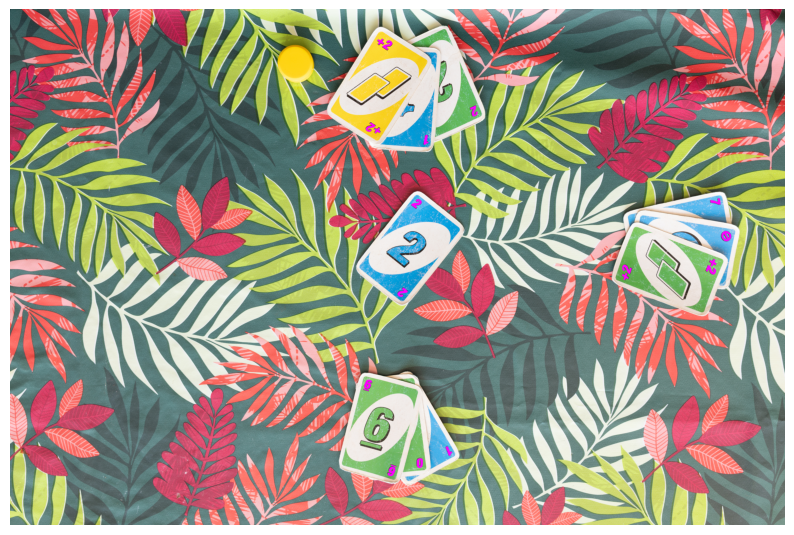

True

In [14]:
symbols_mask_per_color = {}
img_color_array = np.array(img_color)
hsv = cv2.cvtColor(img_color_array, cv2.COLOR_BGR2HSV)
white_by_hsv = (hsv[:, :, 1] <= 40).astype(np.uint8)

for col, mask in color_masks.items():
    if col == "white":
        continue

    hole_mask = helpers.get_holes(mask, min_hole_area=100)

    hole_mask_filtered = helpers.filter_shapes_by_dilated_ring_overlap_binary(
        hole_mask,
        color_masks["white"],
        dilation_radius=20,
        min_white_pixels=50
    )
    hole_mask_filtered = cv2.dilate(
        hole_mask_filtered,
        np.ones((3, 3), dtype=np.uint8),
        iterations=1
    )
    
    # Keep only pixels that are also white in the original image
    hole_mask_filtered = cv2.bitwise_and(
        hole_mask_filtered,
        white_by_hsv
    )
    hole_mask_filtered = helpers.open(3, 1, hole_mask_filtered)

    symbols_mask_per_color[col] = hole_mask_filtered

total_hole_mask = np.bitwise_or.reduce(list(symbols_mask_per_color.values()))
        
holes_in_color_filtered = np.array(img_color).copy()
holes_in_color_filtered[total_hole_mask > 0] = [255, 0, 255]  # magenta for holes

plt.figure(figsize=(10, 8))
plt.imshow(holes_in_color_filtered)
plt.axis("off")
plt.show()

cv2.imwrite("holes_visualization.png", cv2.cvtColor(holes_in_color_filtered, cv2.COLOR_RGB2BGR))

In [ ]:
SYMBOL_PATCH_SIZE = 150
SYMBOL_MERGE_DISTANCE = 20
SYMBOL_OUTPUT_ROOT = BASE_DIR / "extracted_symbols"

try:
    current_image_path = Path(image_path)
except NameError:
    current_image_path = Path(getattr(img_color, "filename", TRAIN_DIR / "L1000973.jpg"))

symbol_output_dir = SYMBOL_OUTPUT_ROOT / current_image_path.stem
symbol_output_dir.mkdir(parents=True, exist_ok=True)


def crop_centered_binary_mask(mask, center_xy, patch_size=150):
    binary_mask = (mask > 0).astype(np.uint8) * 255
    h, w = binary_mask.shape
    cx, cy = center_xy

    left = int(round(cx)) - patch_size // 2
    top = int(round(cy)) - patch_size // 2
    right = left + patch_size
    bottom = top + patch_size

    src_left = max(left, 0)
    src_top = max(top, 0)
    src_right = min(right, w)
    src_bottom = min(bottom, h)

    dst_left = src_left - left
    dst_top = src_top - top

    patch = np.zeros((patch_size, patch_size), dtype=np.uint8)
    patch[
        dst_top:dst_top + (src_bottom - src_top),
        dst_left:dst_left + (src_right - src_left)
    ] = binary_mask[src_top:src_bottom, src_left:src_right]

    return patch


def extract_merged_symbol_patches(mask, merge_distance=20, patch_size=150):
    binary_mask = (mask > 0).astype(np.uint8)

    if not np.any(binary_mask):
        return []

    merge_kernel_size = 2 * int(np.ceil(merge_distance / 2)) + 1
    merge_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (merge_kernel_size, merge_kernel_size)
    )
    merged_mask = cv2.dilate(binary_mask, merge_kernel, iterations=1)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        merged_mask,
        connectivity=8
    )

    patches = []
    for label in range(1, num_labels):
        component_region = labels == label
        original_pixels = binary_mask & component_region.astype(np.uint8)

        if not np.any(original_pixels):
            continue

        ys, xs = np.where(original_pixels > 0)
        center_xy = (xs.mean(), ys.mean())
        patch = crop_centered_binary_mask(binary_mask * original_pixels, center_xy, patch_size)

        patches.append({
            "patch": patch,
            "center_xy": center_xy,
            "area": int(original_pixels.sum()),
            "bbox": tuple(stats[label, :4]),
        })

    return patches


saved_symbol_paths = []

for color, symbol_mask in symbols_mask_per_color.items():
    symbol_patches = extract_merged_symbol_patches(
        symbol_mask,
        merge_distance=SYMBOL_MERGE_DISTANCE,
        patch_size=SYMBOL_PATCH_SIZE
    )

    for symbol_idx, symbol in enumerate(symbol_patches, start=1):
        output_path = symbol_output_dir / f"{color}_symbol_{symbol_idx:02d}.png"
        cv2.imwrite(str(output_path), symbol["patch"])
        saved_symbol_paths.append(output_path)

saved_symbol_paths


Saved 14 symbol masks to /Users/JC/Desktop/Image Analysis/IAPR_gr69/project/extracted_symbols/L1000973


[PosixPath('/Users/JC/Desktop/Image Analysis/IAPR_gr69/project/extracted_symbols/L1000973/blue_symbol_01.png'),
 PosixPath('/Users/JC/Desktop/Image Analysis/IAPR_gr69/project/extracted_symbols/L1000973/blue_symbol_02.png'),
 PosixPath('/Users/JC/Desktop/Image Analysis/IAPR_gr69/project/extracted_symbols/L1000973/blue_symbol_03.png'),
 PosixPath('/Users/JC/Desktop/Image Analysis/IAPR_gr69/project/extracted_symbols/L1000973/blue_symbol_04.png'),
 PosixPath('/Users/JC/Desktop/Image Analysis/IAPR_gr69/project/extracted_symbols/L1000973/blue_symbol_05.png'),
 PosixPath('/Users/JC/Desktop/Image Analysis/IAPR_gr69/project/extracted_symbols/L1000973/blue_symbol_06.png'),
 PosixPath('/Users/JC/Desktop/Image Analysis/IAPR_gr69/project/extracted_symbols/L1000973/green_symbol_01.png'),
 PosixPath('/Users/JC/Desktop/Image Analysis/IAPR_gr69/project/extracted_symbols/L1000973/green_symbol_02.png'),
 PosixPath('/Users/JC/Desktop/Image Analysis/IAPR_gr69/project/extracted_symbols/L1000973/green_symbol